<a href="https://colab.research.google.com/github/ayaaayaaayaaayaaayaaayaa/1G3k6bk3eE5jS72tEbvvYEclhIGrEHNuA/blob/main/Data_Cleaning_%2B_algorithms_(_B_AND_G).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np


# هدف (ب)

In [ ]:
import pandas as pd
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/dirty_cafe_sales (2).csv")
df = df.drop_duplicates()
print(df.head())
#استكشاف البيانات
print(df.info())
print(df.describe())



  Transaction ID    Item Quantity Price Per Unit Total Spent  Payment Method  \
0    TXN_1961373  Coffee        2            2.0         4.0     Credit Card   
1    TXN_4977031    Cake        4            3.0        12.0            Cash   
2    TXN_4271903  Cookie        4            1.0       ERROR     Credit Card   
3    TXN_7034554   Salad        2            5.0        10.0         UNKNOWN   
4    TXN_3160411  Coffee        2            2.0         4.0  Digital Wallet   

   Location Transaction Date  
0  Takeaway       2023-09-08  
1  In-store       2023-05-16  
2  In-store       2023-07-19  
3   UNKNOWN       2023-04-27  
4  In-store       2023-06-11  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   obj

In [ ]:
import pandas as pd
import numpy as np
# تحميل البيانات
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/dirty_cafe_sales (2).csv")
# عرض البيانات قبل التنظيف
print("قبل التنظيف")
display(df.head())

# تحويل عمود التاريخ إلى صيغة تاريخ صحيحة
# اي كانت التواريخ تنسياقتها مختلف تم توحيد التنسيقات
df["Transaction Date"] = pd.to_datetime(df["Transaction Date"], errors="coerce")

#بهذا كود يجب ان اعدل علية لان يوجد خطأ
# استبدال القيم غير المعروفة أو الخاطئة بقيم مفقودة
df.replace(["UNKNOWN", "Unknown", "ERROR", "Error"], np.nan, inplace=True)


#تم استبدال القيم غير المنطقية يعني هكذا : (مثل Error) بقيمة NaN لتنظيف البيانات   النصية الذي يمنع العمليات الحسابية
# مما يتيح لخوارزميات الذكاء الاصطناعي معالجتها كقيم مفقودة
# بدلاً من التعامل معها كبيانات خاطئة تؤدي لتوقف الكود أو إفساد النتائج



# تحويل الأعمدة الرقمية إلى أرقام
# ليش تم استخدامه من شان التأكد ان الاعمدة رقم من شان ما يطلع خطأ بالاكواد
#تبدأ حلقة تكرار (loop) تمر على كل اسم عمود في القائمة
numeric_columns = ["Quantity", "Price Per Unit", "Total Spent"]
for col in numeric_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]
#نوع رقمي (int أو float)
# بضمن كود  ان كل قيمة رقمية
#بعد التأكد من أن الأعمدة "Quantity" و "Price Per Unit" تحتوي على بيانات رقمية
# يتم إنشاء عمود جديد اسمه "Total Spent" عن طريق ضرب القيم الموجودة في عمود "Quantity" بالقيم الموجودة في عمود "Price Per Unit" لكل صف
# للتعامل مع الأرقام المخزنة كنصوصnumeric

# حذف الصفوف التي تحتوي على بيانات أساسية مفقودة
# بيانات مش موجودة
df.dropna(subset=["Transaction Date", "Item", "Quantity"], inplace=True)

# تعويض القيم المفقودة في الأعمدة النصية بالقيمة الأكثر تكرارًا
# سيتم استخدام ال(mode)
df["Payment Method"] = df["Payment Method"].fillna(df["Payment Method"].mode()[0])
df["Location"] = df["Location"].fillna(df["Location"].mode()[0])

# إعادة حساب إجمالي الإنفاق للتأكد من صحة القيم
# اي التأكد من ان القيم صحيحة وليست خاطئة
df["Total Spent"] = df["Quantity"] * df["Price Per Unit"]

# حذف القيم غير المنطقية مثل القيم السالبة أو الصفرية
df = df[(df["Quantity"] > 0) & (df["Price Per Unit"] > 0)]

# عرض البيانات بعد التنظيف
print("بعد التنظيف")
display(df.head())

#from google.colab import files
#files.download("Clean_coffee_shop_sales.csv")





# شرح كود  evidently
from evidently import Report
from evidently.presets import DataDriftPreset
from evidently.ui.workspace import CloudWorkspace

# === تجهيز بيانات train و test ===
train = df.iloc[:-int(0.2*len(df))].copy()
test = df.iloc[-int(0.2*len(df)):].copy()

# زيادة Drift مصطنع في test
test['Total Spent'] *= 1.5

# الأعمدة الأساسية
cols = ['Quantity', 'Price Per Unit', 'Total Spent']
ref_df, cur_df = train[cols], test[cols]

# إنشاء تقرير Data Drift
report = Report(metrics=[DataDriftPreset()])
evaluation = report.run(reference_data=ref_df, current_data=cur_df)

# رفع التقرير على Evidently Cloud
ws = CloudWorkspace(
    token="sk_prod.019c8039-241b-742c-821f-5e1e767dc972.GtZ1kPDVohwO11dkIDluTagHO3xD7Ny-EWa7Qdo9PT6y7BuE0groK9TbdlWblAwtswEiqZ7LMzjZts84jbRIxALfGuyjnRh9syj6eCrdk1DCyzUR3oNHCZ3keNcLcRYX",
    url="https://app.evidently.cloud"
)
project = ws.get_project("019c7529-8feb-70e8-b373-df59a8fb2cbb")
ws.add_run(project.id, evaluation, include_data=False)

print("تم رفع التقرير على Evidently Cloud")


قبل التنظيف


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


بعد التنظيف


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,4.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Digital Wallet,Takeaway,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


بالملخص تم عمل هذي الاكواد لتنظيف البيانات :

عرض البيانات قبل التنظيف

تحويل عمود التاريخ إلى صيغة صحيحة (datetime)

استبدال القيم الخاطئة أو غير المعروفة ب NaN

تحويل الأعمدة الرقمية إلى أرقام (Quantity/ Price Per Unit/ Total Spent)

حذف الصفوف التي تحتوي على بيانات أساسية مفقودة (Transaction Date/ Item/  Quantity)

تعويض القيم المفقودة في الأعمدة النصية بالقيمة الأكثر تكرارًا (Payment Method/ Location)

إعادة حساب إجمالي الإنفاق (Total Spent = Quantity * Price Per Unit)

حذف القيم غير المنطقية (قيمة صفرية أو سالبة في Quantity أو Price Per Unit)

عرض البيانات بعد التنظيف

حفظ البيانات النظيفة في نفس الملف






# تم تنظيف البيانات  هدف (ب)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# هدف (ج ) خوارزميات

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")


# LinearRegression خوارزمية / الانحدار الخطي

In [ ]:
!pip install  evidently

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 237.8/237.8 kB 22.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 567.6/567.6 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.4/57.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 224.9/224.9 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.2/62.2 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.5/71.5 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 82.1 MB/s eta 0:00:00


Mean Squared Error: 3.1229181461416107


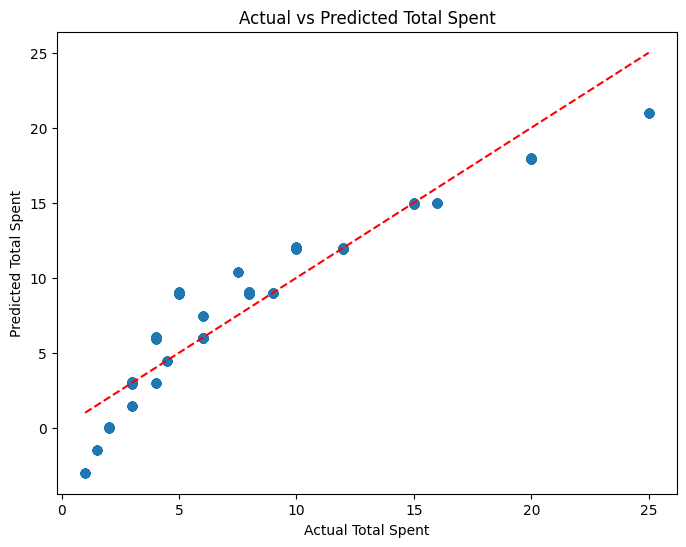

تم رفع التقرير على Evidently Cloud


In [ ]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import pandas as pd # Import pandas

# Load the DataFrame (added this line to resolve the NameError)
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# نسخ وتنظيف البيانات (التأكد أن Total Spent رقم)
#يعيد تصفية الجدول للاحتفاظ فقط بالصفوف التي تحقق الشرط الرقمي أي القيم الصحيحة في Total Spent اي اجمالي الانفاق
df_lr = df.copy()
df_lr = df_lr[df_lr['Total Spent'].astype(str).str.replace('.', '', regex=False).str.isdigit()]
df_lr['Total Spent'] = df_lr['Total Spent'].astype(float)

# تحديد المتغيرات (المدخلات والمخرجات)
X = df_lr[['Quantity', 'Price Per Unit']]
y = df_lr['Total Spent']

# تقسيم البيانات إلى تدريب واختبار
#random_state
#هو فقط رقم لتثبيت العشوائية عند تقسيم البيانات


# تقسيم البيانات إلى 80% تدريب و 20% اختبار
X_train_features, X_test_features, y_train_sales, y_test_sales = train_test_split(X, y, test_size=0.2, random_state=42)

# تقسيم بيانات التدريب إلى 70% تدريب و 10% تحقق (Validation)
X_train_features, X_val_features, y_train_sales, y_val_sales = train_test_split(X_train_features, y_train_sales, test_size=0.125, random_state=42)

# تدريب نموذج الانحدار الخطي
#دالة fit() تقوم بتدريب النموذج على البيانات
model = LinearRegression()
model.fit(X_train, y_train)

# التنبؤ وحساب الخطأ
#دالة predict() من كائن النموذج model تقوم بتوقع المخرجات بناءً على بيانات المدخلات الجديدة
#الناتج y_pred هو قائمة التنبؤات الإجمالية (Total Spent) لكل صف في X_test.
#MSE يحسب الفرق بين القيم المتوقعة والفعلية لكل صف ثم يربع الفرق ويأخذ المتوسط.
y_pred = model.predict(X_test)
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

# رسم القيم الحقيقية مقابل القيم المتوقعة
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Total Spent")
plt.ylabel("Predicted Total Spent")
plt.title("Actual vs Predicted Total Spent")
plt.show()










# شرح كود  evidently
!pip install evidently # Ensure Evidently is installed
from evidently import Report
from evidently.presets import DataDriftPreset
from evidently.ui.workspace import CloudWorkspace

# === تجهيز بيانات train و test ===
train = df.iloc[:-int(0.2*len(df))].copy()
test = df.iloc[-int(0.2*len(df)):].copy()

# زيادة Drift مصطنع في test
test['Total Spent'] *= 1.5

# الأعمدة الأساسية
cols = ['Quantity', 'Price Per Unit', 'Total Spent']
ref_df, cur_df = train[cols], test[cols]

# إنشاء تقرير Data Drift
report = Report(metrics=[DataDriftPreset()])
evaluation = report.run(reference_data=ref_df, current_data=cur_df)

# رفع التقرير على Evidently Cloud
ws = CloudWorkspace(
    token="sk_prod.019c8039-241b-742c-821f-5e1e767dc972.GtZ1kPDVohwO11dkIDluTagHO3xD7Ny-EWa7Qdo9PT6y7BuE0groK9TbdlWblAwtswEiqZ7LMzjZts84jbRIxALfGuyjnRh9syj6eCrdk1DCyzUR3oNHCZ3keNcLcRYX",
    url="https://app.evidently.cloud"
)
project = ws.get_project("019c7529-8feb-70e8-b373-df59a8fb2cbb")
ws.add_run(project.id, evaluation, include_data=False)

print("تم رفع التقرير على Evidently Cloud")

# accuracy

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

X = df[['Quantity', 'Price Per Unit']]
y = df['Total Spent'].astype(float)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = r2_score(y_test, y_pred)
print("Accuracy:", accuracy)
#إجمالي الإنفاق (Total Spent) بناءً على الكمية وسعر الوحدة



Accuracy: 0.912728251597436


# ARIMA – لتوقع المبيعات الزمنية

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so inferred frequency D will be used.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

No frequency information was provided, so infe

Best ARIMA order: (5, 5, 5)
Lowest Mean Squared Error: 632.624907547201
Forecast: 2023-12-27    174.499810
2023-12-28    171.011600
2023-12-29    143.614220
2023-12-30    137.135517
2023-12-31    124.136759
Freq: D, Name: predicted_mean, dtype: float64
Silhouette Score: 0.487471002055534
K-Means Inertia: 1728.0790272249094


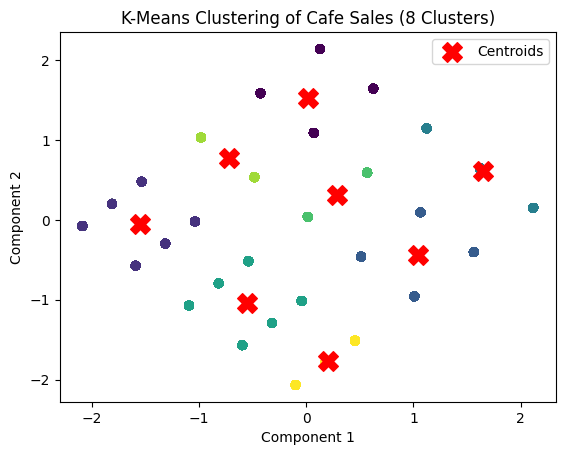

In [ ]:
# استيراد مكتبة pandas للتعامل مع الجداول وملفات CSV
import pandas as pd

# استيراد نموذج ARIMA من مكتبة statsmodels لتطبيق التنبؤات الزمنية
from statsmodels.tsa.arima.model import ARIMA

# استيراد دالة mean_squared_error لحساب دقة التنبؤات
from sklearn.metrics import mean_squared_error

# استيراد مكتبة itertools لتسهيل تجربة مجموعات مختلفة من معاملات النموذج
import itertools

# تحميل ملف البيانات النظيفة لمبيعات المقاهي
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# تحويل التاريخ إلى صيغة زمنية وترتيب البيانات حسب التاريخ
ts = pd.to_datetime(df.groupby('Transaction Date')['Total Spent'].sum().sort_index().index)

# إنشاء سلسلة زمنية للمبيعات اليومية
#تبدأ دالهgroupby بتقسيم الجدول إلى مجموعات فرعية بناءً على قيم عمود معين
data = df.groupby('Transaction Date')['Total Spent'].sum()

# تقسيم البيانات إلى مجموعة تدريب (كل البيانات إلا آخر 5 أيام) ومجموعة اختبار (آخر 5 أيام)
train, test = data[:-5], data[-5:]

# تهيئة متغيرات لاختيار أفضل نموذج بناءً على أقل MSE
best_mse, best_model, best_order = float('inf'), None, None

# تجربة كل التركيبات الممكنة للمعاملات p,d,q من 0 إلى 5 لاختيار أفضل إعدادات للنموذج
for order in itertools.product(range(6), repeat=3):
    try:
        # تدريب نموذج ARIMA على بيانات التدريب بالإعداد الحالي
        model = ARIMA(train, order=order).fit()

        # التنبؤ بقيم الأيام الخمس القادمة
        forecast = model.forecast(steps=5)

        # حساب مربع الخطأ بين التنبؤات والبيانات الفعلية/Validation
        mse = mean_squared_error(test, forecast)

        # حفظ النموذج إذا كان MSE أقل من أفضل قيمة تم العثور عليها
        if mse < best_mse: best_mse, best_model, best_order = mse, model, order
    except:
        pass  # تجاهل أي أخطاء تحدث أثناء تجربة إعدادات غير مناسبة

# طباعة أفضل إعدادات ARIMA التي أعطت أقل MSE
print("Best ARIMA order:", best_order)

# طباعة أقل قيمة لمربع الخطأ
print("Lowest Mean Squared Error:", best_mse)

# طباعة التنبؤات باستخدام أفضل نموذج
print("Forecast:", best_model.forecast(steps=5))


 #كود evidently
#from evidently.ui.workspace import CloudWorkspace
#ws = CloudWorkspace(
   # token="sk_prod.019c8039-241b-742c-821f-5e1e767dc972.GtZ1kPDVohwO11dkIDluTagHO3xD7Ny-EWa7Qdo9PT6y7BuE0groK9TbdlWblAwtswEiqZ7LMzjZts84jbRIxALfGuyjnRh9syj6eCrdk1DCyzUR3oNHCZ3keNcLcRYX",
   # url="https://app.evidently.cloud"
#)
#project = ws.get_project("019c7529-8feb-70e8-b373-df59a8fb2cbb")
#ws.add_run(project.id, evaluation, include_data=False)
#print("تم رفع التقرير على Evidently Cloud")


# accuracy

In [ ]:
from sklearn.metrics import mean_squared_error

# افترض أن 'test' هي بيانات الاختبار و 'forecast' هي التنبؤات من النموذج
# حساب MSE بين التنبؤات والقيم الفعلية
mse = mean_squared_error(test, forecast)

# حساب Accuracy كنسبة مئوية تقريبية
accuracy = 100 * (1 - mse / test.var())

# طباعة القيمة
print("Accuracy (%):", round(accuracy, 2))


Accuracy (%): 24.65


# K-Means – لتجميع المعاملات المتشابهة حسب الكمية والسعر

K-Means Inertia (Error measure) on Training set: 237.60563489152946
Silhouette Score on Validation set: 0.8250774589183718


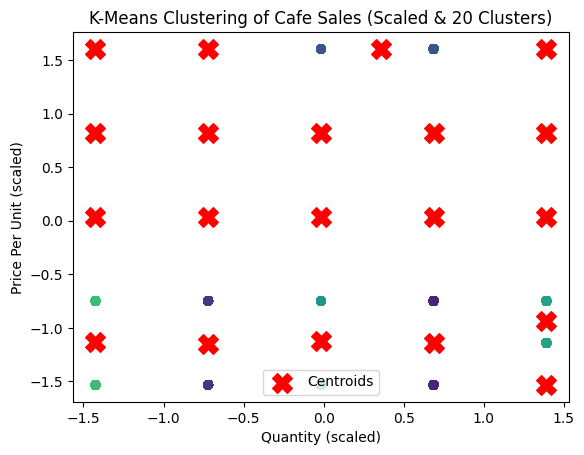

تم رفع التقرير على Evidently Cloud


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# تحميل البيانات النظيفة
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# اختيار الخصائص للتجميع
X_kmeans = df[['Quantity', 'Price Per Unit']]

# تطبيع البيانات
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_kmeans)

# تقسيم البيانات إلى تدريب و تحقق (Validation)
X_train_scaled, X_val_scaled = train_test_split(X_scaled, test_size=0.2, random_state=42)

# نموذج K-Means مع عدد كبير جدًا من المجموعات وعدد محاولات عالي
kmeans = KMeans(n_clusters=20, random_state=42, n_init=200)

# تدريب النموذج على بيانات التدريب
kmeans.fit(X_train_scaled)

# تخزين المجموعات على بيانات التدريب
train_clusters = kmeans.predict(X_train_scaled)

# حساب Inertia على بيانات التدريب
train_inertia = kmeans.inertia_
print("K-Means Inertia (Error measure) on Training set:", train_inertia)

# فلادايشن: التنبؤ بالمجموعات على بيانات التحقق وحساب Silhouette Score
val_clusters = kmeans.predict(X_val_scaled)
val_silhouette = silhouette_score(X_val_scaled, val_clusters)
print("Silhouette Score on Validation set:", val_silhouette)

# تخزين المجموعات النهائية على كامل البيانات للرسم
df['Cluster'] = kmeans.predict(X_scaled)

# رسم النقاط والمراكز
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=df['Cluster'], cmap='viridis', alpha=0.6)
plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], c='red', s=200, marker='X', label='Centroids')
plt.xlabel('Quantity (scaled)')
plt.ylabel('Price Per Unit (scaled)')
plt.title('K-Means Clustering of Cafe Sales (Scaled & 20 Clusters)')
plt.legend()
plt.show()




#كود evidently

import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from evidently import Report
from evidently.presets import DataDriftPreset
from evidently.ui.workspace import CloudWorkspace

df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")
X_scaled = StandardScaler().fit_transform(df[['Quantity','Price Per Unit']])
df['Cluster'] = KMeans(n_clusters=20, random_state=42, n_init=200).fit_predict(X_scaled)

train, test = df.iloc[:-int(0.2*len(df))], df.iloc[-int(0.2*len(df)):]
report = Report(metrics=[DataDriftPreset()])
evaluation = report.run(reference_data=train.reset_index(), current_data=test.reset_index())

ws = CloudWorkspace(token="sk_prod.019c8039-241b-742c-821f-5e1e767dc972.GtZ1kPDVohwO11dkIDluTagHO3xD7Ny-EWa7Qdo9PT6y7BuE0groK9TbdlWblAwtswEiqZ7LMzjZts84jbRIxALfGuyjnRh9syj6eCrdk1DCyzUR3oNHCZ3keNcLcRYX", url="https://app.evidently.cloud")
ws.add_run(ws.get_project("019c7529-8feb-70e8-b373-df59a8fb2cbb").id, evaluation, include_data=False)
print("تم رفع التقرير على Evidently Cloud")

# Accuracy

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
# تحميل البيانات واختيار الخصائص ثم تطبيعها
X = StandardScaler().fit_transform(
    pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")[['Quantity','Price Per Unit']]
)
# تقسيم البيانات إلى مجموعة تدريب ومجموعة اختبار للفلاديشن
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
# تدريب نموذج K-Means على مجموعة التدريب
kmeans = KMeans(n_clusters=20, random_state=42, n_init=200).fit(X_train)
# حساب جودة التجميع على بيانات الاختبار وتحويلها إلى نسبة مئوية
validation_accuracy = silhouette_score(X_test, kmeans.predict(X_test)) * 100
# طباعة نتيجة الفلاديشن
print("Validation Accuracy (%):", round(validation_accuracy, 2))

Validation Accuracy (%): 82.51


# مع استخدتم مكتبة scikit-learn

Silhouette Score: 0.38739850455114944


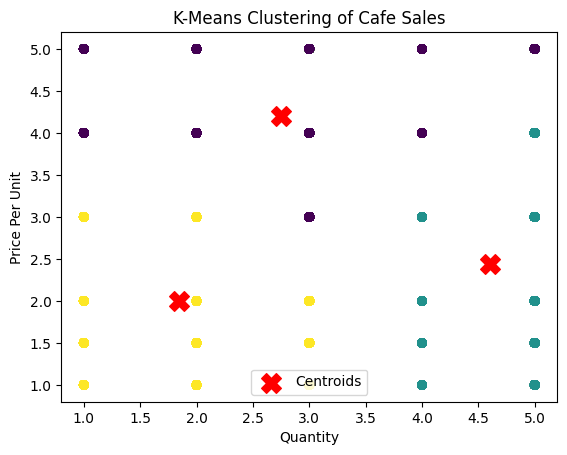

In [ ]:
# استيراد الأدوات من مكتبة scikit-learn وماتبلوتليب للرسم
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# اختيار الخصائص للتجميع من البيانات
X_kmeans = df_lr[['Quantity', 'Price Per Unit']]

# إنشاء نموذج K-Means من scikit-learn مع 3 مجموعات
kmeans = KMeans(n_clusters=3, random_state=42)

# تدريب النموذج وتخزين رقم المجموعة لكل صف
df_lr['Cluster'] = kmeans.fit_predict(X_kmeans)

# حساب مؤشر Silhouette لتقييم جودة التجمعات باستخدام scikit-learn
score = silhouette_score(X_kmeans, df_lr['Cluster'])
print("Silhouette Score:", score)

# رسم نقاط البيانات ملونة حسب المجموعة
plt.scatter(df_lr['Quantity'], df_lr['Price Per Unit'], c=df_lr['Cluster'], cmap='viridis', alpha=0.6)

# رسم مراكز المجموعات
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

# إضافة التسميات والعنوان
plt.xlabel('Quantity')
plt.ylabel('Price Per Unit')
plt.title('K-Means Clustering of Cafe Sales')
plt.legend()
plt.show()


# كود Mane  واجهه المستخدم

In [ ]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# قراءة البيانات
df = pd.read_csv("/content/drive/MyDrive/Data Cleaning (B AND G)/Clean_coffee_shop_sales.csv")

# تنظيف البيانات
df = df[df['Total Spent'].astype(str).str.replace('.', '', regex=False).str.isdigit()]
df['Total Spent'] = df['Total Spent'].astype(float)

# تحديد المتغيرات
X = df[['Quantity', 'Price Per Unit']]
y = df['Total Spent']

# تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# تدريب النموذج
model = LinearRegression()
model.fit(X_train, y_train)

print("✅ Model Trained Successfully")

# إدخال المستخدم
quantity = float(input("Enter Quantity: "))
price = float(input("Enter Price Per Unit: "))

input_data = np.array([[quantity, price]])
prediction = model.predict(input_data)

print("💰 Expected/ spending  Total sales:", round(prediction[0], 2))


✅ Model Trained Successfully
Enter Quantity: 9
Enter Price Per Unit: 5
💰 Expected/ spending  Total sales: 32.77


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


# evidently

In [ ]:
!pip install evidently

In [ ]:

from sklearn import datasets

from evidently import Dataset
from evidently import DataDefinition
from evidently import Report
from evidently.presets import DataDriftPreset, DataSummaryPreset

In [ ]:
from evidently.ui.workspace import CloudWorkspace

In [ ]:
ws = CloudWorkspace(token="sk_prod.019c752c-7e60-74e7-8155-77af8b591f9f.kxZKgOrnm_gl7qcQj1gSRC8fOiBdPwDe5Iwsd6yk6ItWkZRA6F9qFN_CIKdOObmANNE6ZtGHpgDfIUXtXNg4y95j7PvGWihZXzP02lsc3LC29fzj-aDnNxRrdu3A9TtK", url="https://app.evidently.cloud")

In [ ]:
project = ws.create_project("algorithms", org_id="019c7529-8feb-70e8-b373-df59a8fb2cbb")
project.description = "Data Cleaning"
project.save()



In [ ]:
adult_data = datasets.fetch_openml(name="adult", version=2, as_frame="auto")
adult = adult_data.frame

# بيانات نمودج &&&&&&&&&&&&&&&&&&&&&&&&&

In [ ]:
adult_ref = adult[~adult.education.isin(["Some-college", "HS-grad", "Bachelors"])]
adult_prod = adult[adult.education.isin(["Some-college", "HS-grad", "Bachelors"])]
schema = DataDefinition(
    numerical_columns=["education-num", "age", "capital-gain", "hours-per-week", "capital-loss", "fnlwgt"],
    categorical_columns=["education", "occupation", "native-country", "workclass", "marital-status", "relationship", "race", "sex", "class"],
    )
eval_data_1 = Dataset.from_pandas(
    pd.DataFrame(adult_prod),
    data_definition=schema
)
eval_data_2 = Dataset.from_pandas(
    pd.DataFrame(adult_ref),
    data_definition=schema
)

In [ ]:
report = Report([
    DataDriftPreset()
])

my_eval = report.run(eval_data_1, eval_data_2)
my_eval